# 6D Pose Estimation

## Initialize


### Initial Setup

In [1]:
import os
import sys
import subprocess
import shutil
from pathlib import Path

REPO_URL = "https://github.com/luigiaceto/6D-pose-estimation.git"
REPO_BRANCH = "baseline-rgb-geometric-depth-v2"
GDRIVE_DATASET_URL = "https://drive.google.com/drive/folders/19ivHpaKm9dOrr12fzC8IDFczWRPFxho7"

EXEC_ENV = "unknown" 

def run_command(command, check=True):
    """Esegue comandi shell."""
    try:
        subprocess.run(command, shell=True, check=check)
    except subprocess.CalledProcessError as e:
        print(f"❌ Errore comando: {command}")
        raise e

def detect_environment():
    """Rileva l'ambiente."""
    if 'google.colab' in sys.modules:
        return 'colab'
    elif os.path.exists('/kaggle'):
        return 'kaggle'
    else:
        return 'local'

def download_and_setup_dataset_gdown(dest_root="datasets/linemod"):
    """
    Funzione Helper per scaricare dataset da GDrive (Usata da Colab e Local).
    """
    dest_path = Path(dest_root)
    
    # Se il dataset esiste già e non è vuoto, saltiamo
    if dest_path.exists() and any(dest_path.iterdir()):
        print("✅ Dataset già presente.")
        return

    print(f"📥 Downloading dataset to {dest_root}...")
    run_command("pip install -q gdown") # Assicura gdown
    
    os.makedirs(dest_path, exist_ok=True)
    # Salviamo la cwd per tornarci dopo
    original_cwd = os.getcwd()
    os.chdir(dest_path)
    
    try:
        # 1. Scarica
        run_command(f'gdown --folder "{GDRIVE_DATASET_URL}" --quiet')
        
        # 2. Gestione Zip
        if os.path.exists("Linemod_preprocessed.zip"):
            print("📦 Unzipping...")
            run_command("unzip -q Linemod_preprocessed.zip")
            run_command("rm Linemod_preprocessed.zip")
        
        # 3. Fix struttura cartelle (se gdown crea sottocartella)
        if os.path.exists("Linemod_preprocessed"):
            print("📂 Adjusting folder structure...")
            run_command("mv Linemod_preprocessed/* .")
            run_command("rmdir Linemod_preprocessed")
            
        print("✅ Dataset Download & Setup Complete.")
        
    except Exception as e:
        print(f"❌ Errore download dataset: {e}")
    finally:
        os.chdir(original_cwd)


# --- LOGICA KAGGLE ---
def setup_kaggle():
    print("🔧 Setup KAGGLE (Robust)...")
    
    # 1. Fix NumPy
    try:
        import numpy
        is_bad = numpy.__version__.startswith("2.")
    except ImportError:
        is_bad = True

    if is_bad:
        print("🚨 NumPy incompatibility detected. Fixing...")
        pkgs = ["numpy", "scipy", "numpy-quaternion", "opencv-python-headless"]
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y"] + pkgs, check=False)
        
        install_pkgs = [
            "numpy==1.26.4", "scipy==1.11.4", "scikit-learn==1.3.2",
            "opencv-python-headless<4.10.0", "numpy-quaternion", "ultralytics", "pyyaml", "tqdm"
        ]
        subprocess.run([sys.executable, "-m", "pip", "install"] + install_pkgs, check=True)
        
        print("\n🛑 STOP: RIAVVIA LA SESSIONE (Run > Restart Session) e riesegui.")
        return False

    # 2. Clone Repo
    os.chdir("/kaggle/working")
    if not os.path.exists("6D-pose-estimation"):
        run_command(f"git clone -q -b {REPO_BRANCH} {REPO_URL}")
    
    repo_path = "/kaggle/working/6D-pose-estimation"
    if repo_path not in sys.path: sys.path.insert(0, repo_path)
    os.chdir(repo_path)

    # 3. Copy Dataset (Kaggle Input -> Working)
    SRC = Path("/kaggle/input/linemod/Linemod_preprocessed") 
    DST = Path("datasets/linemod")
    if not DST.exists():
        print("📦 Copia dataset da Input (veloce)...")
        shutil.copytree(SRC, DST, dirs_exist_ok=True)
    
    os.environ["WANDB_MODE"] = "disabled"
    return True

# --- LOGICA COLAB (MODIFICATA: NO DRIVE) ---
def setup_colab():
    print("🔧 Setup COLAB (Direct Download)...")
    
    # 1. Clone Repo
    if not os.path.exists('/content/6D-pose-estimation'):
        run_command(f"git clone -b {REPO_BRANCH} {REPO_URL} /content/6D-pose-estimation")
    else:
        os.chdir('/content/6D-pose-estimation')
        run_command("git pull")
    
    os.chdir('/content/6D-pose-estimation')
    
    # 2. Install Dependencies
    print("📦 Installing requirements...")
    run_command("pip install -q -r requirements.txt")
    
    # 3. DOWNLOAD DATASET (Niente Drive, scarica in locale VM)
    download_and_setup_dataset_gdown(dest_root="datasets/linemod")
    
    # Creiamo cartella checkpoints se non esiste
    os.makedirs("checkpoints", exist_ok=True)
    
    return True

# --- LOGICA LOCALE ---
def setup_local():
    print("🔧 Setup LOCAL...")
    if os.path.exists("requirements.txt"):
        run_command("pip install -q -r requirements.txt")
    
    download_and_setup_dataset_gdown(dest_root="datasets/linemod")
    return True

# --- MAIN ---
EXEC_ENV = detect_environment()

if EXEC_ENV == 'kaggle':
    if not setup_kaggle():
        EXEC_ENV = "kaggle_needs_restart" # Flag speciale
elif EXEC_ENV == 'colab':
    setup_colab()
else:
    setup_local()

print(f"\n🌍 Environment: {EXEC_ENV}")
if EXEC_ENV != "kaggle_needs_restart":
    print(f"📂 CWD: {os.getcwd()}")
    print("✅ Setup Completato.")

🔧 Setup LOCAL...
✅ Dataset già presente.

🌍 Environment: local
📂 CWD: /Users/luigi/Documents/MSc-PoliTO/II_anno/AML/progetto/6D-pose-estimation
✅ Setup Completato.


Get working directory:

Handle imports

In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='pydantic')

from torch.utils.data import DataLoader
from pathlib import Path

from utils.init import set_seed
from utils.init import set_device
from utils.data_exploration import get_camera_intrinsics

set_seed(42)

device = set_device()

if EXEC_ENV == "kaggle": 
    dataset_root = Path("/kaggle/working/6D-pose-estimation/datasets/linemod")
    yolo_path = Path("/kaggle/working/6D-pose-estimation/datasets/linemod/YOLO/datasets")
    checkpoint_best_yolo_path = Path("/kaggle/input/chekpoint") / "best_yolo_model.pt"
    checkpoint_best_pose_path = Path("/kaggle/input/chekpoint") / "best_pose_model.pt"
else:
    dataset_root = Path("datasets") / "linemod" / "DenseFusion" / "Linemod_preprocessed"
    yolo_path = Path("datasets") / "linemod" / "YOLO" / "datasets"
    checkpoint_best_yolo_path = Path("checkpoints") / "best_yolo_model.pt"
    checkpoint_best_pose_path = Path("checkpoints") / "best_pose_model.pt"

cam_k = get_camera_intrinsics(dataset_root)

### Dataset Preprocessing

Copy ground truth files to ```Linemod_preprocessed```:

In [3]:
from utils.data_exploration import get_class_names
from utils.preprocessing import copy_gt_file, change_02gt, quaternion_gt

folder_names = get_class_names(dataset_root)

In [4]:
copy_gt_file(dataset_root, folder_names)

Change ```02_gt.yml``` to take only one object:

In [5]:
change_02gt(str(dataset_root / "02_gt.yml"))

Add quaternion:

In [6]:
quaternion_gt(dataset_root)

### Data Exploration

Load an image to check if it's all ok:

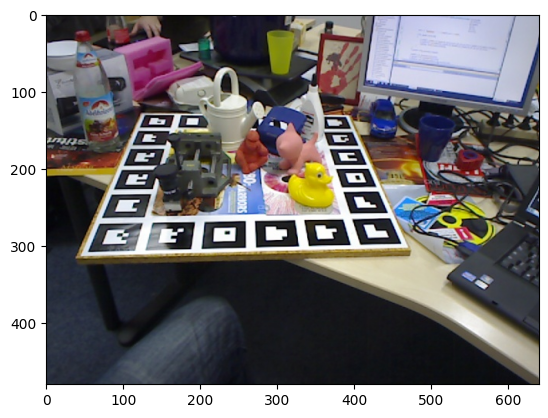

In [7]:
from utils.data_exploration import load_image

load_image(dataset_root, label=1, object=0)

### Define the Custom Dataset

In [8]:
from data.CustomDatasetPose import CustomDatasetPose

train_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="train",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)
val_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="validation",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)
test_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="test",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Training samples: 12640
Validation samples: 1580
Testing samples: 1580


### Visualize data

Visualize depth image:

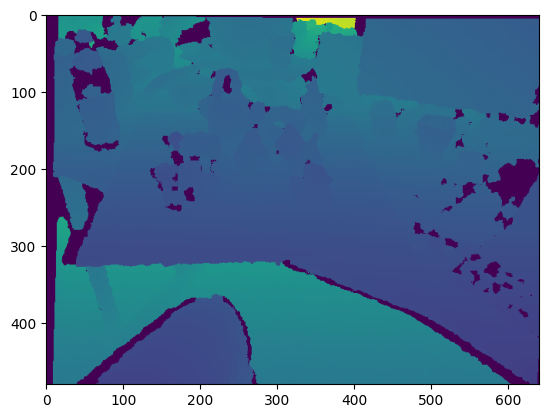

In [9]:
from utils.data_exploration import load_depth_image

folder = "01"
object_name = "0000"

img = load_depth_image(str(dataset_root / "data" / f"{folder}" / "depth" / f"{object_name}.png"))

Plot the patch of first object of the image, it reads from the ground truth file containing also multiple objects in one image:

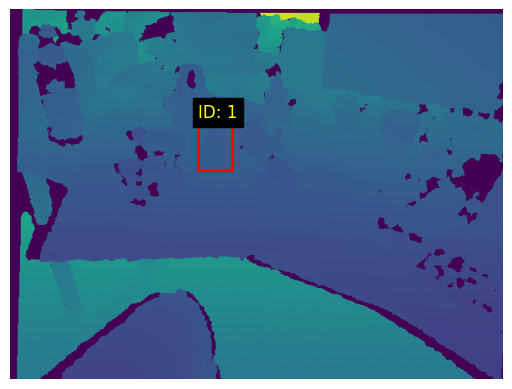

In [10]:
from utils.data_exploration import load_depth_patch

load_depth_patch(dataset_root, folder, object_name, img)

Get data loader:

In [11]:
# Dataloader per visualizzazione (batch piccolo)
viz_train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
viz_val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
viz_test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Visualization - Training loader: {len(viz_train_loader)}")
print(f"Visualization - Validation loader: {len(viz_val_loader)}")
print(f"Visualization - Test loader: {len(viz_test_loader)}")

Visualization - Training loader: 3160
Visualization - Validation loader: 395
Visualization - Test loader: 395


Plot one batch of data:

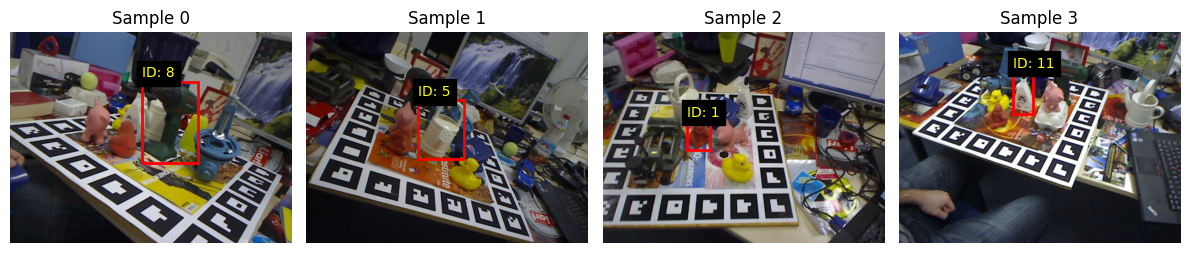

In [12]:
from utils.data_exploration import plot_batch_data

plot_batch_data(viz_train_loader, viz_val_loader, viz_test_loader)

## YOLO

### Data Preprocessing for YOLO

In [14]:
train_samples = train_dataset.get_samples_id()
validation_samples = val_dataset.get_samples_id()
test_samples = test_dataset.get_samples_id()

Create a new folder containing all the info for YOLO, we just need the rgb image and a text file with the label and bounding box.
The ```Linemod_preprocessed``` is not removed, as it contains info about translation and rotation that are needed for pose estimation, but not for YOLO object detection model.

Create YOLO yaml:

In [15]:
from utils.preprocessing import create_YOLO_yaml

number_classes, class_names = create_YOLO_yaml(folder_names)

While creating the folder structure, we have to change the class id by using the index in the array written in the ```data.yaml```:

In [16]:
# create a dictionary to have easily access to the index. Dato che usiamo un sottoinsieme
# di folder di LineMOD
index_dict = dict()
for index, elem in enumerate(class_names):
    index_dict[int(elem)] = index

Create the folders:

In [ ]:
from utils.preprocessing import create_dataset_YOLO

if (yolo_path / "train" / "images").exists() and len(list((yolo_path / "train" / "images").glob("*"))) > 0:
    print("Dataset YOLO già creato.")
    counter_df = None  
else:
    print("Creazione dataset YOLO in corso (può richiedere qualche minuto)...")
    counter_df = create_dataset_YOLO(
        number_classes, 
        train_samples, 
        validation_samples, 
        test_samples, 
        index_dict, 
        train_dataset
    )
    print("Dataset YOLO creato con successo!")

Dataset YOLO già creato, skip preprocessing.


Visualize dataset distribution:

In [18]:
from utils.data_exploration import load_dataset_distribution

if counter_df is not None:
    load_dataset_distribution(counter_df, index_dict, number_classes)
else:
    print("⏭️  Skipped: Dataset distribution già visualizzato in precedenza.")

⏭️  Skipped: Dataset distribution già visualizzato in precedenza.


In [19]:
# YOLO Training Configuration
yolo_config = {
    "img_size": 640,
    "epochs": 20,
    "batch_size": 64
}

print(f"YOLO Configuration: {yolo_config}")


YOLO Configuration: {'img_size': 640, 'epochs': 20, 'batch_size': 64}


### Train YOLO

**[TRAINING ONLY]**

In [ ]:
from yolo_train import train_YOLO

train_YOLO(
    epochs=yolo_config["epochs"],
    batch_size=yolo_config["batch_size"],
    img_size=yolo_config["img_size"],
    device=device,
    yolo_dataset_path=yolo_path,
    checkpoint_dir="checkpoints"
)

### Evaluate YOLO

In [20]:
from yolo_evaluate import evaluate_YOLO

yolo_results = evaluate_YOLO(
    epochs=yolo_config["epochs"],
    batch_size=yolo_config["batch_size"],
    img_size=yolo_config["img_size"],
    device=device,
    yolo_dataset_path=yolo_path,
    model_path=checkpoint_best_yolo_path
)

YOLO11n summary (fused): 100 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 390.2171.6 MB/s, size: 463.7 KB)
val: Scanning C:\Users\Davide\OneDrive\Documenti\Universita\Magistrale\Corsi\Advance machine learning\project\6D-pose-estimation\datasets\linemod\YOLO\datasets\test\labels.cache... 3156 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3156/3156 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.0s/it 1:381.4sss
                   all       3156       3156      0.999      0.999      0.995      0.953
                    01        249        249          1      0.993      0.995      0.931
                    02        247        247      0.999          1      0.995      0.962
                    04        242        242          1          1      0.995      0.942
                    05        231        231      0.999          1      0.995      0.

### Visualize YOLO

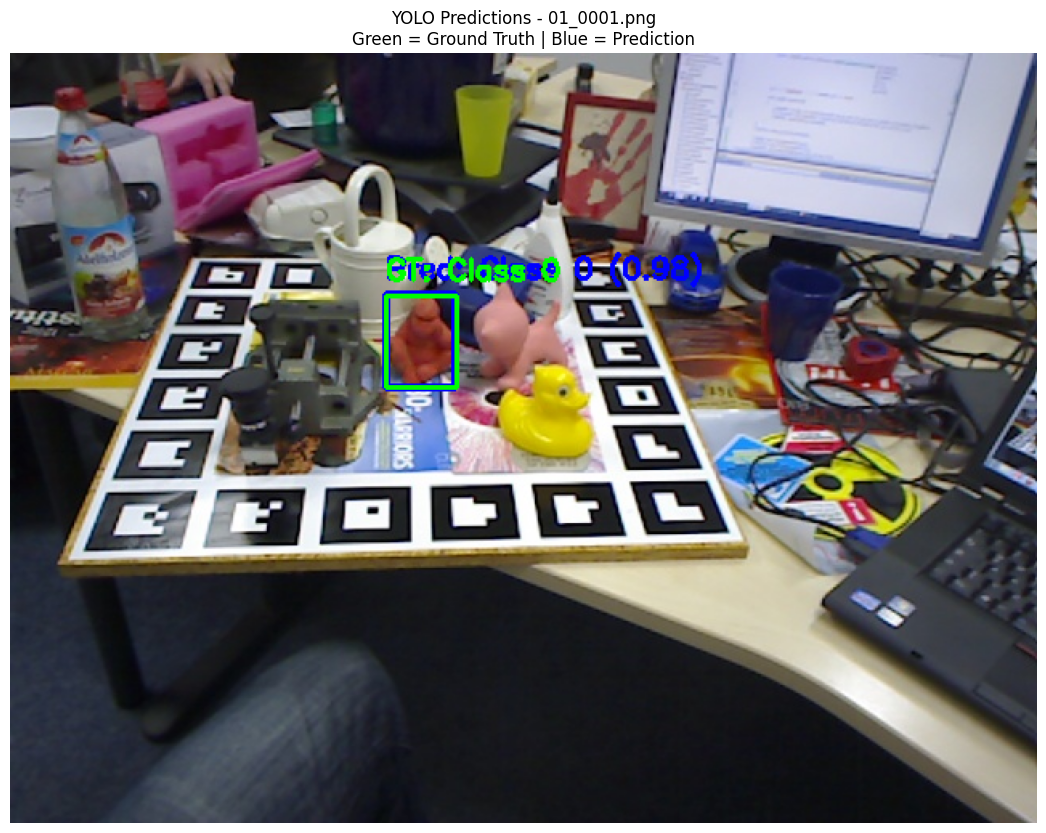


01_0001.png:
  Predictions: 1 boxes detected


In [21]:
import importlib
import yolo_visualize
importlib.reload(yolo_visualize)
from yolo_visualize import visualize_yolo_predictions

visualize_yolo_predictions(
    yolo_model_path=checkpoint_best_yolo_path,
    yolo_dataset_path=yolo_path,
    img_size=yolo_config["img_size"],
    conf_threshold=0.5,
    num_images=1
)

## 6D Pose Estimation (Baseline)

### Setup Model and Configuration

In [ ]:
if EXEC_ENV == "kaggle":
    config = {
        "num_workers": 4,          # Usa tutte le CPU di Kaggle
        "batch_size": 128,         # Alto per stabilizzare i gradienti
        "num_epochs": 100,         
        "learning_rate": 2e-4,     # Leggermente più alto per batch 128
        "weight_decay": 1e-4,      # Più alto per evitare overfitting su dataset piccolo
        "freeze_epochs": 0    
    }

else:
    config = {
        "num_workers": 2,         
        "batch_size": 32,          
        "num_epochs": 100,         
        "learning_rate": 1e-4,     
        "weight_decay": 1e-6,      
        "freeze_epochs": 0         
    }
    
print(f"Using device: {device}")
print(f"Configuration: {config}")

Using device: cuda
Configuration: {'num_workers': 2, 'batch_size': 32, 'num_epochs': 100, 'learning_rate': 0.0001, 'weight_decay': 1e-06, 'freeze_epochs': 0}


### Training 6D Pose Model

In [10]:
from baseline_train import train

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=config["num_workers"],
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=True,
    persistent_workers=True
)

# Set to None for fresh training, or path to checkpoint to resume
resume_checkpoint = None  # or str(Path("checkpoints") / "best_pose_model.pt")

train(
    train_dataset=train_dataset,
    train_loader=train_loader,
    val_loader=val_loader,
    cam_k=cam_k,
    checkpoint_dir="checkpoints",
    epochs=config["num_epochs"],
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"],
    device=device,
    freeze_epochs=config["freeze_epochs"],
    resume_from_checkpoint=resume_checkpoint
)

print("\nTraining complete!")

Mixed Precision (AMP): ENABLED

Epoch 1/100
  [Warmup] LR: 0.000033


Validation: 100%|██████████| 50/50 [00:53<00:00,  1.08s/it]


Train Loss: 0.3546 | Val Loss: 0.1476 | Avg Rot Error: 45.90°
✓ Saved best model (Err: 45.90°)

Epoch 2/100
  [Warmup] LR: 0.000067


Validation: 100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


Train Loss: 0.1165 | Val Loss: 0.0632 | Avg Rot Error: 26.86°
✓ Saved best model (Err: 26.86°)

Epoch 3/100
  [Warmup] LR: 0.000100


...

Train Loss: 0.0098 | Val Loss: 0.0083 | Avg Rot Error: 6.52°

Epoch 99/100


Validation: 100%|██████████| 50/50 [00:38<00:00,  1.31it/s]


Train Loss: 0.0098 | Val Loss: 0.0079 | Avg Rot Error: 6.34°
✓ Saved best model (Err: 6.34°)

Epoch 100/100


Validation: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]


Train Loss: 0.0095 | Val Loss: 0.0077 | Avg Rot Error: 6.21°
✓ Saved best model (Err: 6.21°)

Training completed!

Training complete! Model saved to checkpoints/best_pose_model.pt


In [ ]:
if EXEC_ENV == "kaggle":
    # Crea cartella output pulita
    output_dir = "/kaggle/working/model_checkpoint"
    os.makedirs(output_dir, exist_ok=True)

    # Copia solo il best model
    source = "/kaggle/working/6D-pose-estimation/checkpoints/best_pose_model.pt"
    dest = os.path.join(output_dir, "best_model.pt")

    if os.path.exists(source):
        shutil.copy(source, dest)
        size = os.path.getsize(dest) / (1024 * 1024)
        
        print(f"✅ Best model saved!")
        print(f"   Location: {dest}")
        print(f"   Size: {size:.2f} MB")
        print(f"\n📥 Download from Output tab: model_checkpoint/best_pose_model.pt")
    else:
        print(f"❌ Best model not found at: {source}")

### Evaluation 6D Pose Model

In [23]:
from baseline_evaluate import evaluate

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=True
)

evaluate(
    dataset_root=dataset_root,
    test_dataset=test_dataset,
    test_loader=test_loader,
    cam_k=cam_k,
    checkpoint_path=checkpoint_best_pose_path,
    device=device,
    save_table=False,
    table_path="./evaluation_results.csv"
)

Evaluating...


100%|██████████| 50/50 [01:27<00:00,  1.75s/it]


,Object Name,#Samples,Accuracy @10% (%),ADD-R Accuracy @10% (%),Rotation Error (deg),Translation Error (cm),ADD / ADD-S (cm),ADD-R (cm)
0,ape,123,0.81,80.49,7.75,12.88,12.94,0.75
1,benchvise,122,14.75,90.16,7.70,11.04,11.31,1.70
2,camera,120,4.17,93.33,6.10,11.29,11.35,0.92
3,can,119,18.49,87.39,6.54,8.86,9.06,1.27
4,cat,118,0.00,94.92,6.62,18.74,18.77,0.84
5,driller,119,1.68,96.64,6.77,13.33,13.43,1.43
6,duck,126,1.59,86.51,6.75,8.03,8.06,0.72
7,eggbox,126,11.90,98.41,5.70,10.73,8.44,0.59
8,glue,122,18.85,99.18,4.18,21.20,17.74,0.53
9,holepuncher,123,1.63,97.56,6.69,15.76,15.80,0.79


### Visualize 6D Pose Predictions


VISUALIZATION: 0060.png

 Object 3 (Class 2)

 GROUND TRUTH:
     Translation: [ 0.0321, -0.0837,  0.7484] m
     Quaternion:  [-0.0451, -0.8764, -0.4636,  0.1219]

 PREDICTION:
     Translation: [ 0.0227, -0.0974,  0.7543] m
     Quaternion:  [ 0.0988,  0.8682,  0.4821, -0.0642]

 ERRORS:
     BBox IoU (2D):        95.15%  ← YOLO detection accuracy
     Translation Error:    1.76 cm
       - X error:  -0.93 cm
       - Y error:  -1.37 cm
       - Z error (depth):   0.59 cm  ← Main issue!
     Rotation Error:       9.33°




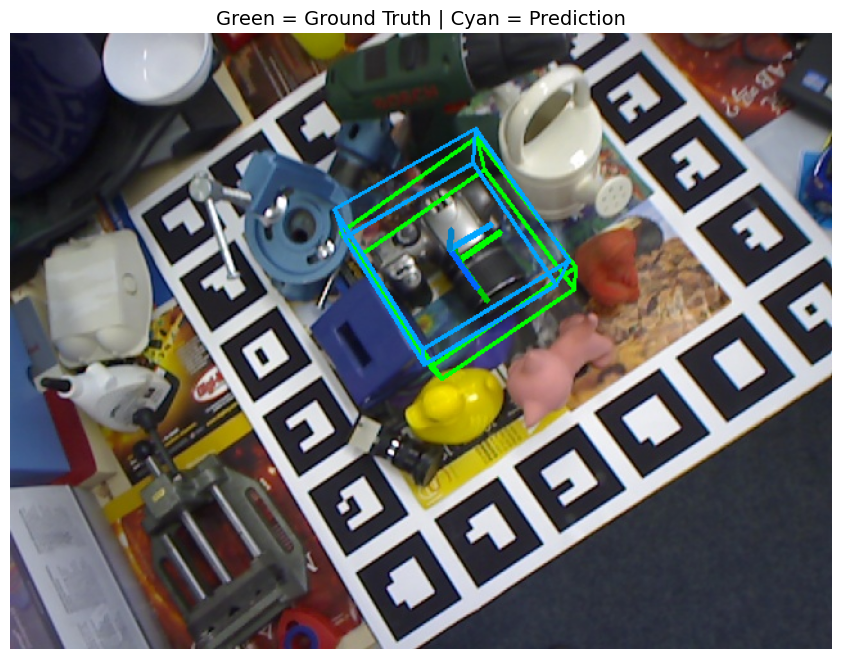

In [7]:
import importlib, baseline_visualize
importlib.reload(baseline_visualize)
from baseline_visualize import visualize_predictions

visualize_predictions(
    dataset_root,
    cam_k=cam_k,
    image_path=str(dataset_root / "data" / "04" / "rgb" / "0060.png"),
    yolo_checkpoint= checkpoint_best_yolo_path,
    pose_checkpoint= checkpoint_best_pose_path,
    device=device,
    img_mean=[0.485, 0.456, 0.406],
    img_std=[0.229, 0.224, 0.225]
)

## Testing YOLO + ResNet Pipeline

In [ ]:
import importlib
import baseline_full_pipeline_test
importlib.reload(baseline_full_pipeline_test)

from baseline_full_pipeline_test import evaluate_full_pipeline

pipeline_test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

evaluate_full_pipeline(
    test_dataset=test_dataset,  
    test_loader=pipeline_test_loader,    
    cam_k=cam_k,
    yolo_checkpoint=checkpoint_best_yolo_path,
    pose_checkpoint=checkpoint_best_pose_path,
    device=device
)

Full Pipeline Eval: 100%|██████████| 1580/1580 [03:34<00:00,  7.37it/s]


FULL PIPELINE DIAGNOSTICS:
Total Samples: 1580
✅ Valid Predictions (Box+Class OK): 1579
❌ Discarded (Wrong Class):        0
❌ Discarded (No Detection):       1



,Object Name,#Samples,Accuracy @10% (%),ADD-R Accuracy @10% (%),Rotation Error (deg),Translation Error (cm),ADD / ADD-S (cm),ADD-R (cm)
0,ape,123,1.63,82.11,7.64,13.00,13.05,0.74
1,benchvise,122,12.30,86.07,6.87,11.46,11.60,1.56
2,camera,120,0.83,91.67,6.45,11.65,11.72,0.97
3,can,119,18.49,89.08,6.73,9.05,9.28,1.30
4,cat,118,0.00,95.76,6.54,19.29,19.31,0.83
5,driller,119,2.52,95.80,6.21,13.79,13.86,1.32
6,duck,126,0.00,83.33,6.98,8.71,8.74,0.75
7,eggbox,125,5.60,99.20,4.22,11.37,8.94,0.56
8,glue,122,16.39,99.18,4.35,22.01,18.44,0.56
9,holepuncher,123,0.81,95.93,7.66,16.16,16.23,0.86
